In [1]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import sqlalchemy

In [2]:
engine = sqlalchemy.create_engine(
    "mssql+pyodbc://localhost/salesproject"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

print("OK")


OK


In [3]:
paises_ventas = pd.read_sql("""SELECT country_name,SUM(mm.units_sold) as 'total_ventas'
FROM dim_country1 as dc
INNER JOIN  
 ev_market_master1 as mm ON dc.country_id = mm.country_id
GROUP BY  country_name
ORDER BY  Total_ventas DESC""",engine)
paises_ventas.columns = ['country_name', 'total_ventas']

top3_raw = pd.read_sql("""SELECT TOP 3 dd.year,dd.month,SUM(mm.units_sold) as 'total_ventas' FROM ev_market_master1 as mm
INNER JOIN 
	dim_date as dd ON mm.date_id = dd.date_id
GROUP BY dd.year,dd.month
ORDER BY total_ventas DESC""", engine)
top3_raw.columns    = ['year', 'month', 'ventas']
top3_raw['periodo'] = (top3_raw['year'].astype(str) + '-' +
                       top3_raw['month'].astype(str).str.zfill(2))
top3_meses = top3_raw

gasolina = pd.read_sql("""SELECT dc.country_name, dd.year,
ROUND(AVG(fpm.gasoline_price_usd_per_liter), 2) as precio_usd
FROM dim_country1 as dc
INNER JOIN fuel_prices_monthly1 as fpm ON dc.country_id = fpm.country_id
INNER JOIN dim_date as dd ON dd.date_id = fpm.date_id
WHERE dd.year BETWEEN 2019 AND 2023
GROUP BY dc.country_name, dd.year
ORDER BY precio_usd DESC""", engine)
gasolina.columns = ['country_name', 'year', 'precio_usd']

cargadores =pd.read_sql("""SELECT dc.country_name,dd.year, MAX(ecm.fast_chargers_cumulative) as 'total_cargadores_rapidos' FROM dim_country1 as dc
INNER JOIN 
ev_charging_monthly1 as ecm ON dc.country_id = ecm.country_id
INNER JOIN
dim_date as dd ON ecm.date_id = dd.date_id
WHERE dd.year = 2023
GROUP BY dc.country_name, dd.year
ORDER BY total_cargadores_rapidos DESC""", engine)
cargadores.columns = ['country_name', 'year', 'rapidos']


In [4]:
PASTEL = ['#C9B8D8', '#A8C4D4', '#B8D4B8', '#D4B8A8',
          '#D4C4A8', '#D4A8B8', '#A8B8D4', '#B8C8A8']

BG   = '#FFFFFF'
GRID = '#F0F0F0'
TEXT = '#333333'
SUB  = '#888888'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    '#DDDDDD',
    'axes.labelcolor':   SUB,
    'xtick.color':       SUB,
    'ytick.color':       SUB,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.linestyle':    '-',
    'grid.alpha':        1.0,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

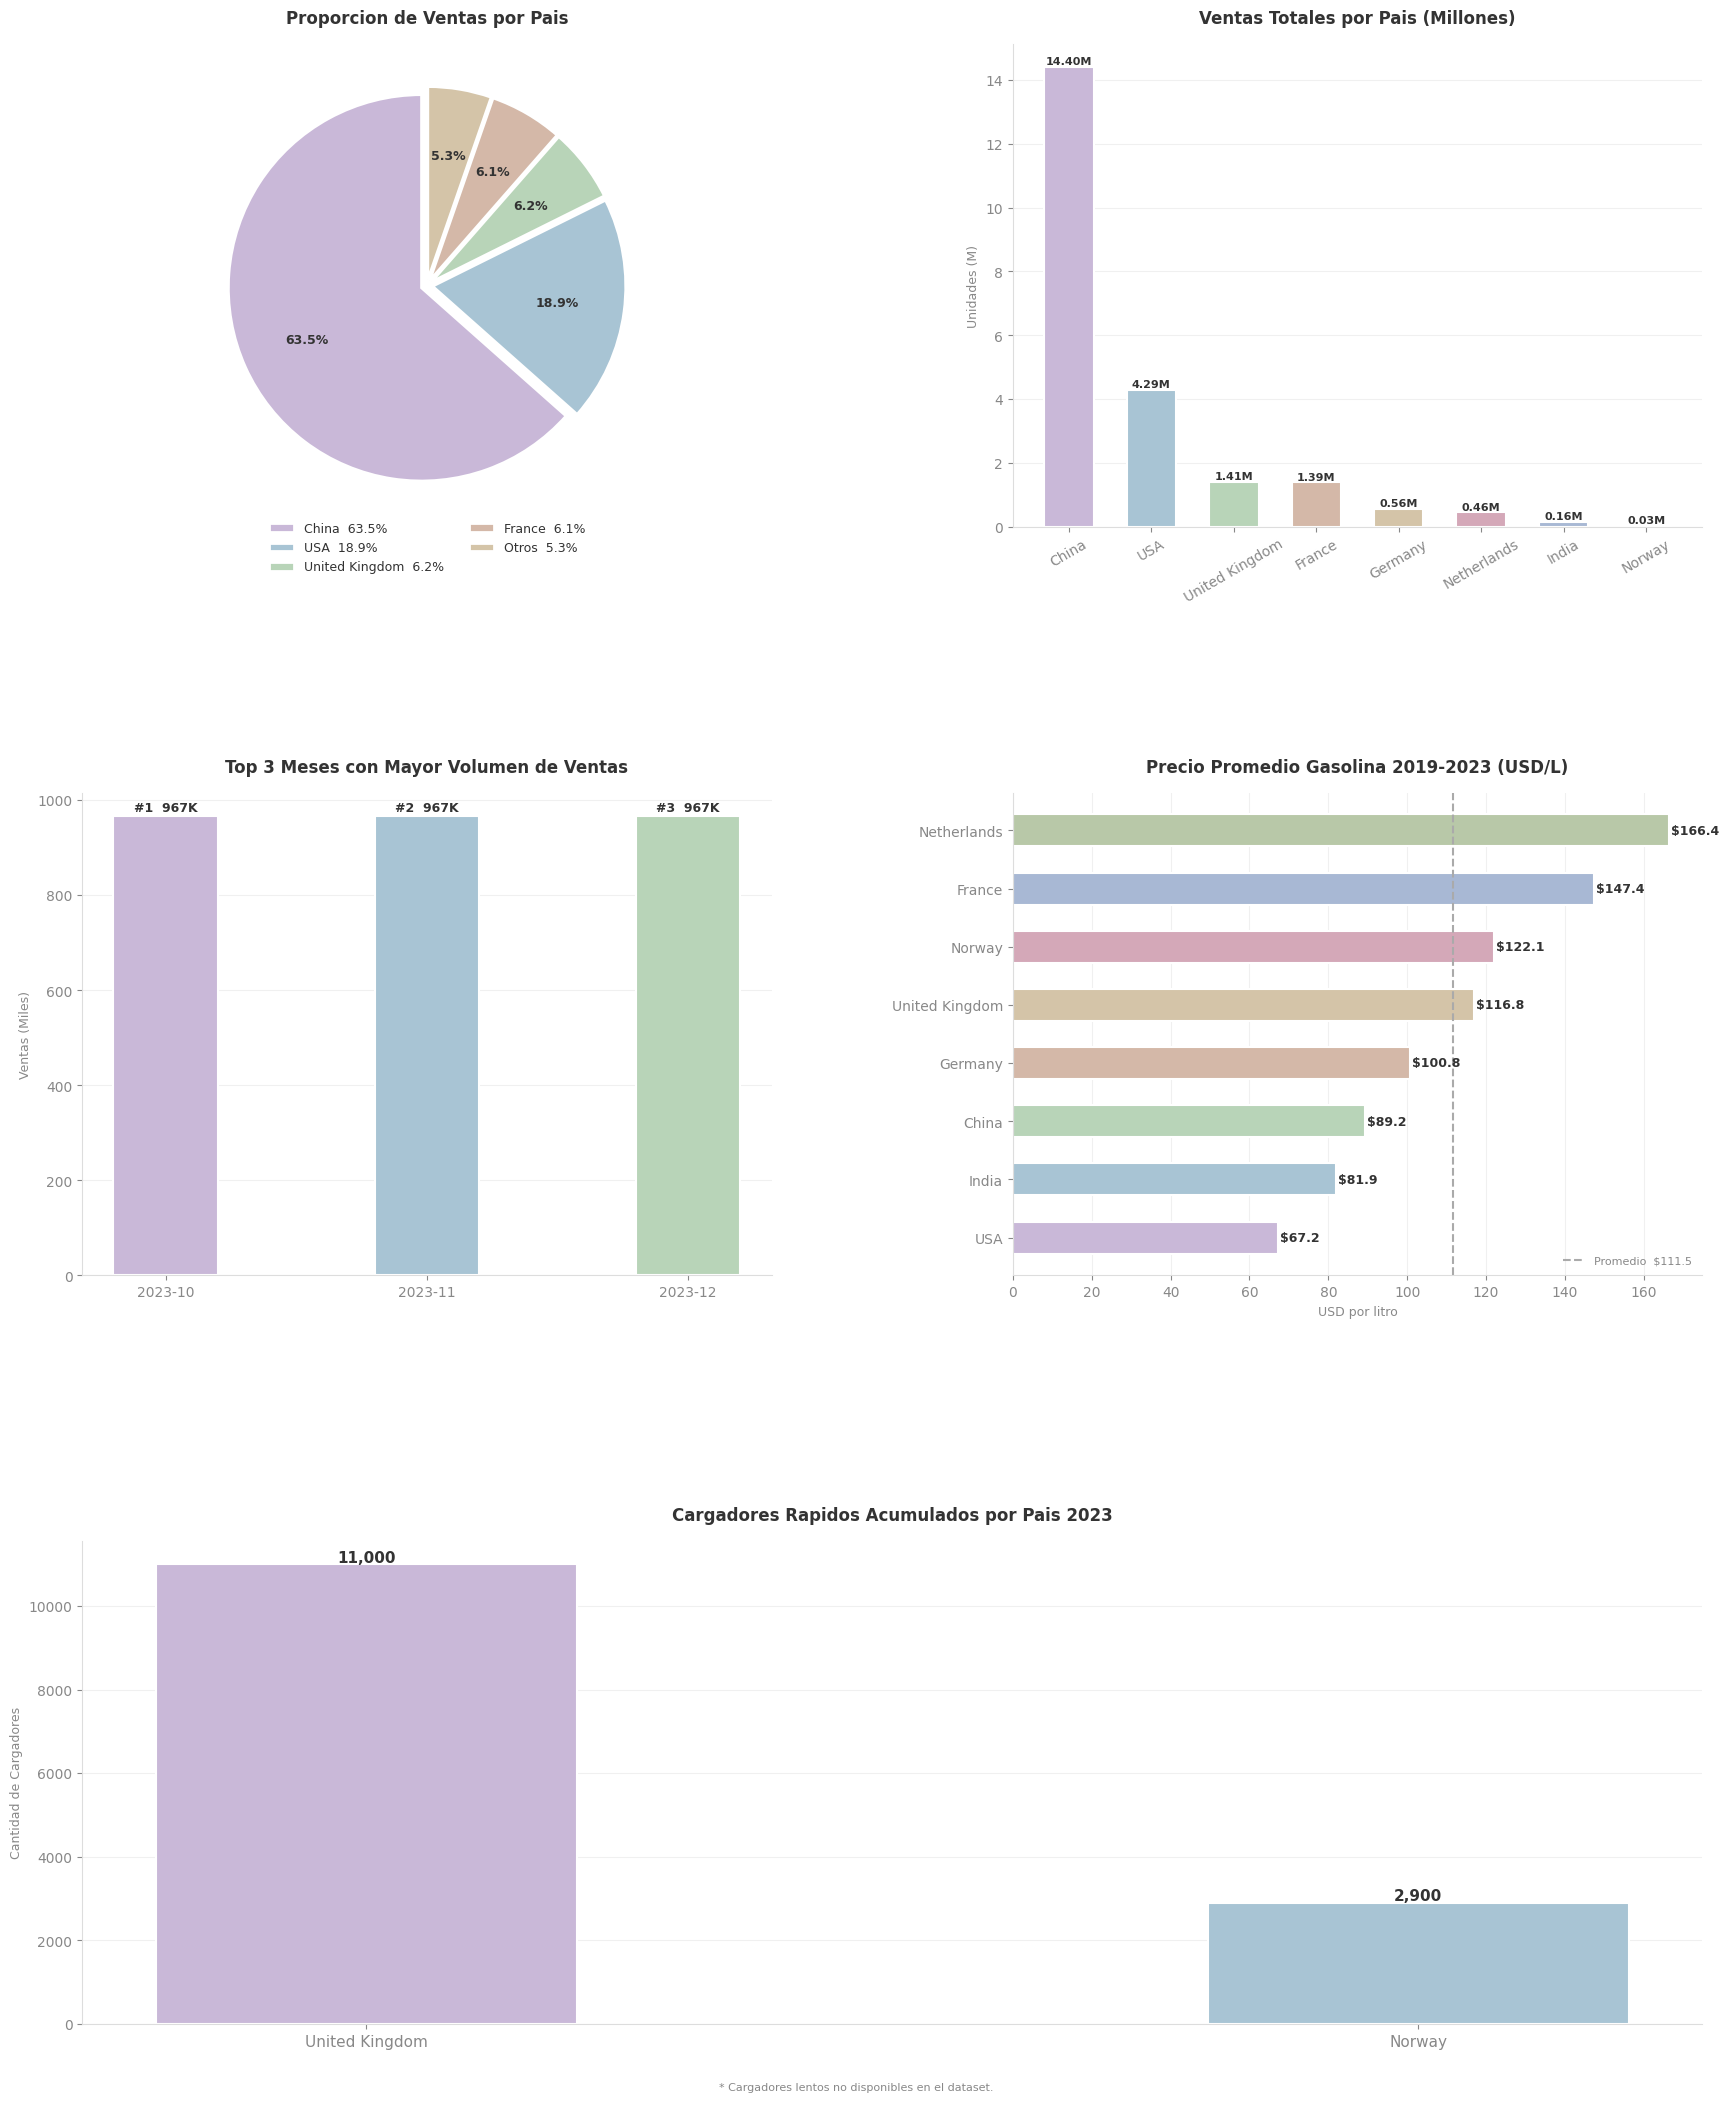

In [21]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
fig.suptitle('',
             fontsize=20, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.55, wspace=0.35,
                       left=0.07, right=0.97,
                       top=0.94, bottom=0.04)

# ------- GRAFICO 1  Pie Chart---------
ax1 = fig.add_subplot(gs[0, 0])
threshold = 0.03
total     = paises_ventas['total_ventas'].sum()
paises_ventas['pct'] = paises_ventas['total_ventas'] / total

grandes = paises_ventas[paises_ventas['pct'] >= threshold].copy()
otros   = paises_ventas[paises_ventas['pct'] <  threshold].copy()

if len(otros) > 0:
    otros_row = pd.DataFrame({
        'country_name': ['Otros'],
        'total_ventas': [otros['total_ventas'].sum()],
        'pct':          [otros['pct'].sum()]
    })
    df_pie = pd.concat([grandes, otros_row], ignore_index=True)
else:
    df_pie = grandes

explode = [0.03] * len(df_pie)
wedges, texts, autotexts = ax1.pie(
    df_pie['total_ventas'],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=PASTEL[:len(df_pie)],
    startangle=90,
    explode=explode,
    pctdistance=0.65,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 0}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
    at.set_color('#333333')

labels_con_pct = [
    f"{row['country_name']}  {row['pct']*100:.1f}%"
    for _, row in df_pie.iterrows()
]
ax1.legend(
    wedges, labels_con_pct,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    fontsize=9, framealpha=0,
    labelcolor='#333333', ncol=2
)
ax1.set_title('Proporcion de Ventas por Pais',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)

# ------- GRAFICO 2 Horizontal Bar Chart--------------
ax2   = fig.add_subplot(gs[0, 1])
df2   = paises_ventas.sort_values('total_ventas', ascending=False)
bars2 = ax2.bar(df2['country_name'],
                df2['total_ventas'] / 1_000_000,
                color=PASTEL[:len(df2)],
                width=0.6, edgecolor='white', linewidth=1.5)
ax2.set_title('Ventas Totales por Pais (Millones)',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax2.set_ylabel('Unidades (M)', color=SUB, fontsize=9)
ax2.tick_params(axis='x', rotation=30)
ax2.yaxis.grid(True, color=GRID)
ax2.set_axisbelow(True)
for bar, val in zip(bars2, df2['total_ventas']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val/1_000_000:.2f}M',
             ha='center', va='bottom',
             fontsize=8, fontweight='bold', color=TEXT)

# --------------- GRAFICO 3  Bar Chart ----------------------
ax3   = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(top3_meses['periodo'],
                top3_meses['ventas'] / 1000,
                color=[PASTEL[0], PASTEL[1], PASTEL[2]],
                width=0.4, edgecolor='white', linewidth=1.5)
ax3.set_title('Top 3 Meses con Mayor Volumen de Ventas',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax3.set_ylabel('Ventas (Miles)', color=SUB, fontsize=9)
ax3.yaxis.grid(True, color=GRID)
ax3.set_axisbelow(True)
for bar, rank, val in zip(bars3, ['#1','#2','#3'], top3_meses['ventas']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{rank}  {val/1000:.0f}K',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=TEXT)

# -------GRAFICO 4  Horizontal Bar Chart----------------
ax4  = fig.add_subplot(gs[1, 1])

df4  = gasolina.groupby('country_name')['precio_usd'].mean().reset_index()
df4  = df4.sort_values('precio_usd', ascending=True)
prom = df4['precio_usd'].mean()

bars4 = ax4.barh(df4['country_name'], df4['precio_usd'],
                 color=PASTEL[:len(df4)],
                 height=0.55, edgecolor='white', linewidth=1.5)
ax4.axvline(prom, color='#AAAAAA', linestyle='--',
            linewidth=1.5, label=f'Promedio  ${prom:.1f}')

ax4.set_title('Precio Promedio Gasolina 2019-2023 (USD/L)',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax4.set_xlabel('USD por litro', color=SUB, fontsize=9)
ax4.xaxis.grid(True, color=GRID)
ax4.set_axisbelow(True)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.legend(fontsize=8, framealpha=0, labelcolor=SUB)

for bar, val in zip(bars4, df4['precio_usd']):
    ax4.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f'${val:.1f}',
             va='center', fontsize=9,
             fontweight='bold', color=TEXT)

# ------------GRAFICO 5  Bar chart cargadores rapidos ------------
ax5   = fig.add_subplot(gs[2, :])
x     = np.arange(len(cargadores['country_name']))
bars5 = ax5.bar(x, cargadores['rapidos'],
                color=PASTEL[:len(cargadores)],
                width=0.4, edgecolor='white', linewidth=1.5)
ax5.set_title('Cargadores Rapidos Acumulados por Pais 2023',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax5.set_ylabel('Cantidad de Cargadores', color=SUB, fontsize=9)
ax5.set_xticks(x)
ax5.set_xticklabels(cargadores['country_name'], fontsize=11)
ax5.yaxis.grid(True, color=GRID)
ax5.set_axisbelow(True)
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{int(bar.get_height()):,}',
             ha='center', fontsize=11,
             fontweight='bold', color=TEXT)

fig.text(0.5, 0.01,
         '* Cargadores lentos no disponibles en el dataset.',
         ha='center', color=SUB, fontsize=8)

plt.savefig('ev_dashboard_pastel.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

In [15]:

q6 = pd.read_sql("""
WITH ventas_totales AS (
    SELECT dc.country_name, db.brand_name,
        SUM(mm.units_sold) as total_ventas,
        RANK() OVER (PARTITION BY country_name 
                     ORDER BY SUM(mm.units_sold) DESC) as ranking
    FROM dim_brand as db
    INNER JOIN ev_market_master1 as mm ON db.brand_id = mm.brand_id
    INNER JOIN dim_country1 as dc ON mm.country_id = dc.country_id
    WHERE db.brand_name IN ('BYD','Tesla','VW')
    GROUP BY db.brand_name, dc.country_name
)
SELECT country_name, brand_name, total_ventas FROM ventas_totales
WHERE ranking = 1
ORDER BY total_ventas DESC
""", engine)
q6.columns = ['country_name', 'brand_name', 'total_ventas']

q7 = pd.read_sql("""
SELECT dc.country_name, dd.year, dd.month, evm.trend_score as puntaje
FROM dim_keyword as dk
INNER JOIN ev_trends_monthly1 as evm ON dk.keyword_id = evm.keyword_id
INNER JOIN dim_date as dd ON evm.date_id = dd.date_id
INNER JOIN dim_country1 as dc ON evm.country_id = dc.country_id
WHERE dk.keyword = 'electric car' AND evm.trend_score > 75
ORDER BY puntaje DESC
""", engine)
q7.columns = ['country_name', 'year', 'month', 'puntaje']

q8 = pd.read_sql("""
WITH ventas_anuales AS (
    SELECT dc.country_name, dd.year,
        AVG(mm.units_sold) as promedio_ventas
    FROM ev_market_master1 as mm
    INNER JOIN dim_date as dd ON mm.date_id = dd.date_id
    INNER JOIN dim_country1 as dc ON dc.country_id = mm.country_id
    GROUP BY dc.country_name, dd.year
),
yoy as (
    SELECT country_name, year, promedio_ventas,
        LAG(promedio_ventas) OVER (PARTITION BY country_name ORDER BY year) as prev_year,
        ROUND((promedio_ventas - LAG(promedio_ventas) OVER (PARTITION BY country_name ORDER BY year)) * 100.0/
        NULLIF(LAG(promedio_ventas) OVER (PARTITION BY country_name ORDER BY year),0), 2) as promedio_crecimiento
    FROM ventas_anuales
)
SELECT country_name, year, promedio_ventas, prev_year, promedio_crecimiento
FROM yoy
WHERE promedio_crecimiento IS NOT NULL
ORDER BY promedio_crecimiento DESC
""", engine)
q8.columns = ['country_name', 'year', 'promedio_ventas', 'prev_year', 'yoy_pct']

q9 = pd.read_sql("""
WITH keyword_promedio as (
    SELECT dc.country_name, dk.keyword,
        ROUND(AVG(tt.trend_score), 2) as promedio_busqueda
    FROM dim_keyword as dk
    INNER JOIN ev_trends_monthly1 as tt ON dk.keyword_id = tt.keyword_id
    INNER JOIN dim_country1 as dc ON tt.country_id = dc.country_id
    GROUP BY dc.country_name, dk.keyword
),
ranking as (
    SELECT *, RANK() OVER(PARTITION BY country_name 
                          ORDER BY promedio_busqueda DESC) as rnk
    FROM keyword_promedio
)
SELECT country_name, keyword, promedio_busqueda FROM ranking
WHERE rnk = 1
ORDER BY promedio_busqueda DESC
""", engine)
q9.columns = ['country_name', 'keyword', 'promedio_busqueda']


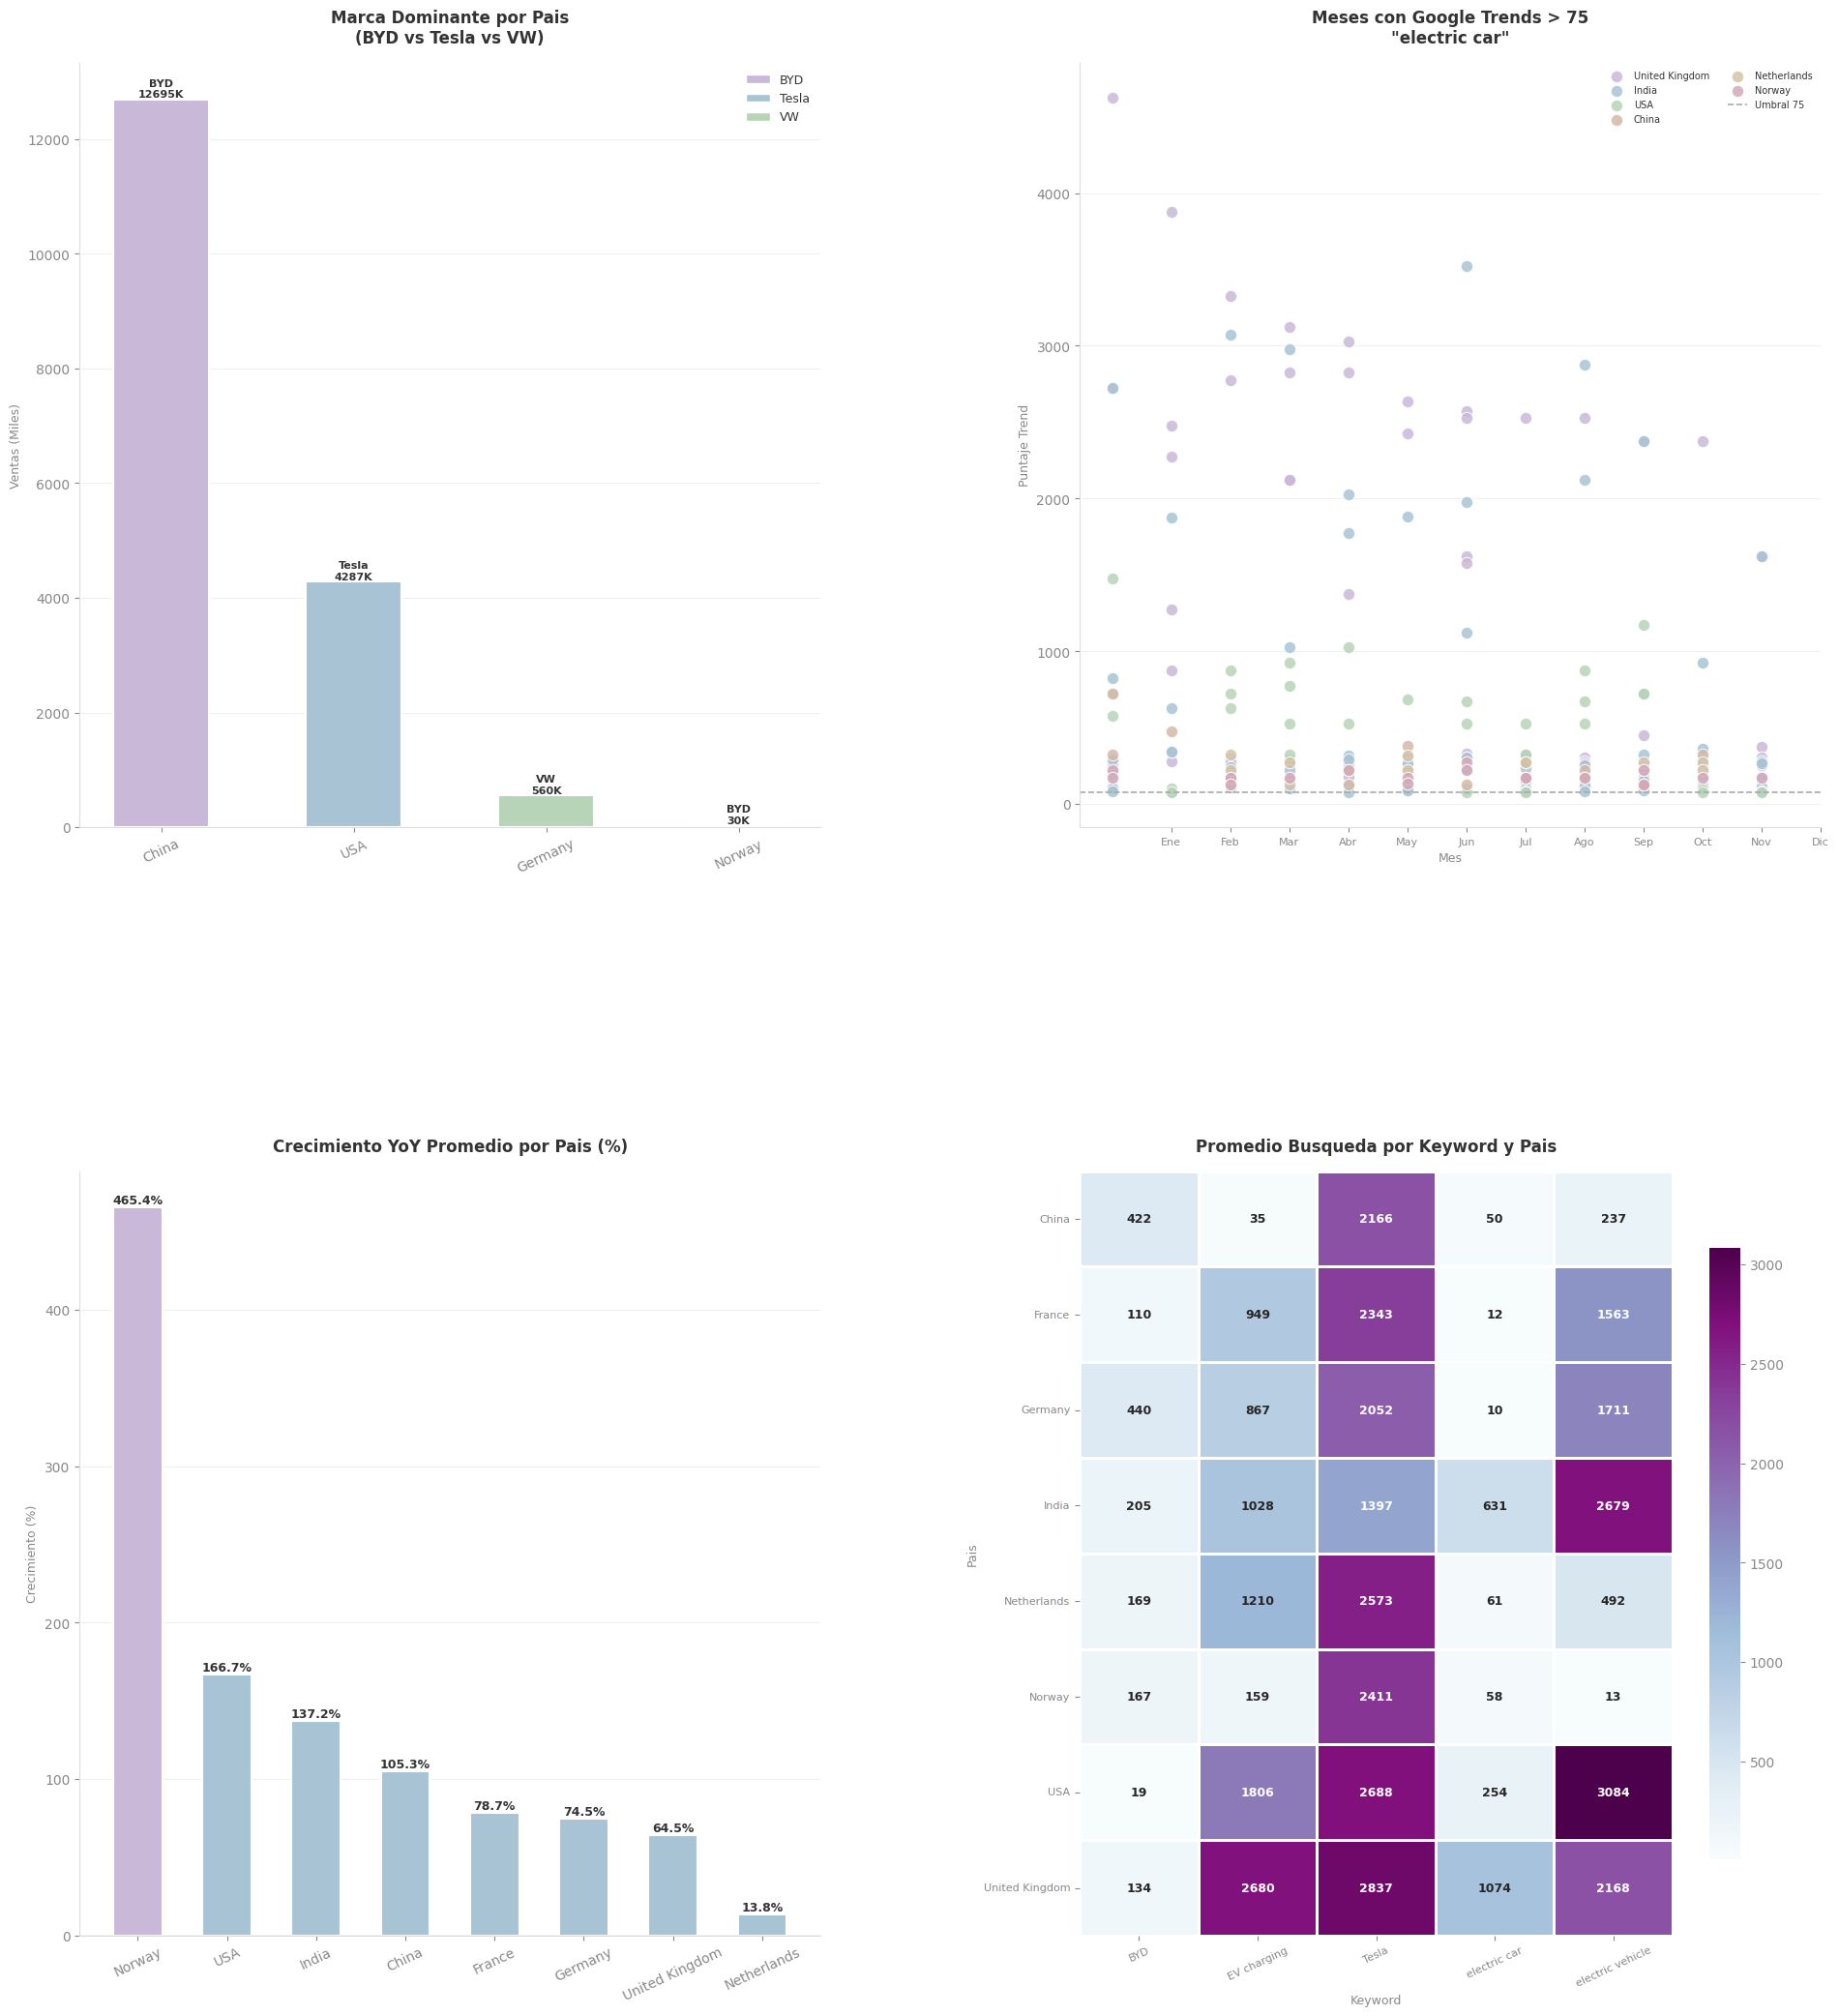

In [18]:
PASTEL = ['#C9B8D8', '#A8C4D4', '#B8D4B8', '#D4B8A8',
          '#D4C4A8', '#D4A8B8', '#A8B8D4', '#B8C8A8']
BG   = '#FFFFFF'
GRID = '#F0F0F0'
TEXT = '#333333'
SUB  = '#888888'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    '#DDDDDD',
    'axes.labelcolor':   SUB,
    'xtick.color':       SUB,
    'ytick.color':       SUB,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.linestyle':    '-',
    'grid.alpha':        1.0,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle('',
             fontsize=20, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97,
                       top=0.93, bottom=0.05)

# ------- GRAFICO 6 Grouped bar chart marca dominante por pais ---------
ax6 = fig.add_subplot(gs[0, 0])
marcas        = q6['brand_name'].unique()
colores_marca = {'BYD': PASTEL[0], 'Tesla': PASTEL[1], 'VW': PASTEL[2]}
x6            = np.arange(len(q6['country_name']))

bars6 = ax6.bar(q6['country_name'], q6['total_ventas'] / 1000,
                color=[colores_marca.get(b, PASTEL[3]) 
                       for b in q6['brand_name']],
                width=0.5, edgecolor='white', linewidth=1.5)

ax6.set_title('Marca Dominante por Pais\n(BYD vs Tesla vs VW)',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax6.set_ylabel('Ventas (Miles)', color=SUB, fontsize=9)
ax6.tick_params(axis='x', rotation=25)
ax6.yaxis.grid(True, color=GRID)
ax6.set_axisbelow(True)

for bar, marca, val in zip(bars6, q6['brand_name'], q6['total_ventas']):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'{marca}\n{val/1000:.0f}K',
             ha='center', va='bottom',
             fontsize=8, fontweight='bold', color=TEXT)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores_marca[m], 
                         edgecolor='white', label=m)
                   for m in colores_marca]
ax6.legend(handles=legend_elements, fontsize=9,
           framealpha=0, labelcolor=TEXT, loc='upper right')

# --------- GRAFICO 7 Scatter plot Google Trends > 75 ----------
ax7 = fig.add_subplot(gs[0, 1])
paises_unicos = q7['country_name'].unique()
colores7      = {p: PASTEL[i % len(PASTEL)] 
                 for i, p in enumerate(paises_unicos)}

for pais in paises_unicos:
    df_p = q7[q7['country_name'] == pais]
    ax7.scatter(df_p['month'], df_p['puntaje'],
                color=colores7[pais], s=80,
                alpha=0.85, label=pais,
                edgecolors='white', linewidth=0.8)

ax7.axhline(75, color='#AAAAAA', linestyle='--',
            linewidth=1.2, label='Umbral 75')
ax7.set_title('Meses con Google Trends > 75\n"electric car"',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax7.set_xlabel('Mes', color=SUB, fontsize=9)
ax7.set_ylabel('Puntaje Trend', color=SUB, fontsize=9)
ax7.set_xticks(range(1, 13))
ax7.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                     'Jul','Ago','Sep','Oct','Nov','Dic'],
                    fontsize=8)
ax7.yaxis.grid(True, color=GRID)
ax7.set_axisbelow(True)
ax7.legend(fontsize=7, framealpha=0,
           labelcolor=TEXT, ncol=2,
           loc='upper right')

# ---------- GRAFICO 8  Bar chart YoY crecimiento --------------------
ax8  = fig.add_subplot(gs[1, 0])
df8  = q8.groupby('country_name')['yoy_pct'].mean().reset_index()
df8  = df8.sort_values('yoy_pct', ascending=False)
cols8 = [PASTEL[0] if v == df8['yoy_pct'].max() 
         else PASTEL[4] if v < 0 
         else PASTEL[1] 
         for v in df8['yoy_pct']]

bars8 = ax8.bar(df8['country_name'], df8['yoy_pct'],
                color=cols8, width=0.55,
                edgecolor='white', linewidth=1.5)
ax8.axhline(0, color='#CCCCCC', linewidth=1)
ax8.set_title('Crecimiento YoY Promedio por Pais (%)',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax8.set_ylabel('Crecimiento (%)', color=SUB, fontsize=9)
ax8.tick_params(axis='x', rotation=25)
ax8.yaxis.grid(True, color=GRID)
ax8.set_axisbelow(True)
for bar, val in zip(bars8, df8['yoy_pct']):
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=TEXT)

# ----------- GRAFICO 9  Heatmap keyword por pais -------------
ax9  = fig.add_subplot(gs[1, 1])
q9_full = pd.read_sql("""
    SELECT dc.country_name, dk.keyword,
        ROUND(AVG(tt.trend_score), 2) as promedio_busqueda
    FROM dim_keyword as dk
    INNER JOIN ev_trends_monthly1 as tt ON dk.keyword_id = tt.keyword_id
    INNER JOIN dim_country1 as dc ON tt.country_id = dc.country_id
    GROUP BY dc.country_name, dk.keyword
""", engine)
q9_full.columns = ['country_name', 'keyword', 'promedio_busqueda']

pivot9 = q9_full.pivot(index='country_name',
                        columns='keyword',
                        values='promedio_busqueda')

sns.heatmap(pivot9, ax=ax9,
            cmap='BuPu',
            annot=True, fmt='.0f',
            linewidths=0.8,
            linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})

ax9.set_title('Promedio Busqueda por Keyword y Pais',
              fontsize=12, fontweight='bold', color=TEXT, pad=15)
ax9.set_xlabel('Keyword', color=SUB, fontsize=9)
ax9.set_ylabel('Pais', color=SUB, fontsize=9)
ax9.tick_params(axis='x', rotation=25, labelsize=8)
ax9.tick_params(axis='y', rotation=0,  labelsize=8)

plt.savefig('ev_dashboard_6_9.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()


In [17]:
q10 = pd.read_sql("""
WITH ventas_actuales as (
    SELECT dc.country_name, dd.year, dd.month, 
        SUM(mm.units_sold) as total_ventas
    FROM ev_market_master1 as mm
    INNER JOIN dim_date as dd ON mm.date_id = dd.date_id
    INNER JOIN dim_country1 as dc ON mm.country_id = dc.country_id
    GROUP BY dc.country_name, dd.year, dd.month
),
ventas_anteriores as (
    SELECT country_name, year, month, total_ventas,
        LAG(total_ventas) OVER (PARTITION BY country_name 
                                ORDER BY year, month) as anterior,
        ROUND(total_ventas - LAG(total_ventas) OVER (PARTITION BY country_name 
                                ORDER BY year, month), 2) as diferencia
    FROM ventas_actuales
),
ranking as (
    SELECT *, RANK() OVER (PARTITION BY country_name 
                           ORDER BY diferencia DESC) as ranking_pais
    FROM ventas_anteriores
)
SELECT country_name, year, month as mes, 
       total_ventas, anterior as ventas_anterior, 
       diferencia, ranking_pais
FROM ranking
WHERE ranking_pais = 1
ORDER BY diferencia DESC
""", engine)
q10.columns = ['country_name','year','mes','total_ventas',
               'ventas_anterior','diferencia','ranking_pais']

q11 = pd.read_sql("""
WITH ventas_mensuales AS (
    SELECT dc.country_name, dd.year, dd.month,
        SUM(mm.units_sold) AS total_ventas
    FROM ev_market_master1 AS mm
    INNER JOIN dim_date AS dd ON mm.date_id = dd.date_id
    INNER JOIN dim_country1 AS dc ON mm.country_id = dc.country_id
    GROUP BY dc.country_name, dd.year, dd.month
),
con_lag AS (
    SELECT country_name, year, month, total_ventas,
        LAG(total_ventas) OVER (PARTITION BY country_name 
                                ORDER BY year, month) AS anterior,
        ROUND(total_ventas - LAG(total_ventas) OVER 
             (PARTITION BY country_name ORDER BY year, month), 2) AS diferencia
    FROM ventas_mensuales
),
ranking AS (
    SELECT *,
        ROW_NUMBER() OVER (             
            PARTITION BY country_name 
            ORDER BY diferencia ASC,    
                     year ASC,          
                     month ASC          
        ) AS rn
    FROM con_lag
    WHERE diferencia IS NOT NULL
)
SELECT country_name, year, month AS mes,
       total_ventas, anterior, diferencia
FROM ranking
WHERE rn = 1
ORDER BY diferencia ASC
""", engine)
q11.columns = ['country_name','year','mes',
               'total_ventas','anterior','diferencia']


q12 = pd.read_sql("""
WITH ventas_anuales AS (
    SELECT dc.country_name, dd.year,
        SUM(mm.units_sold) AS ventas_pais
    FROM ev_market_master1 AS mm
    INNER JOIN dim_country1 AS dc ON mm.country_id = dc.country_id
    INNER JOIN dim_date AS dd ON mm.date_id = dd.date_id
    GROUP BY dc.country_name, dd.year
),
total_por_anio AS (
    SELECT year, SUM(ventas_pais) AS ventas_globales
    FROM ventas_anuales
    GROUP BY year
),
mejor_anio AS (
    SELECT TOP 1 year FROM total_por_anio
    ORDER BY ventas_globales DESC
),
porcentaje AS (
    SELECT va.country_name, va.year, va.ventas_pais,
        tp.ventas_globales,
        ROUND(va.ventas_pais * 100.0 / tp.ventas_globales, 2) AS porcentaje
    FROM ventas_anuales AS va
    INNER JOIN total_por_anio AS tp ON va.year = tp.year
    WHERE va.year = (SELECT year FROM mejor_anio)
)
SELECT country_name, year, ventas_pais, 
       ventas_globales, porcentaje
FROM porcentaje
ORDER BY porcentaje DESC
""", engine)
q12.columns = ['country_name','year','ventas_pais',
               'ventas_globales','porcentaje']


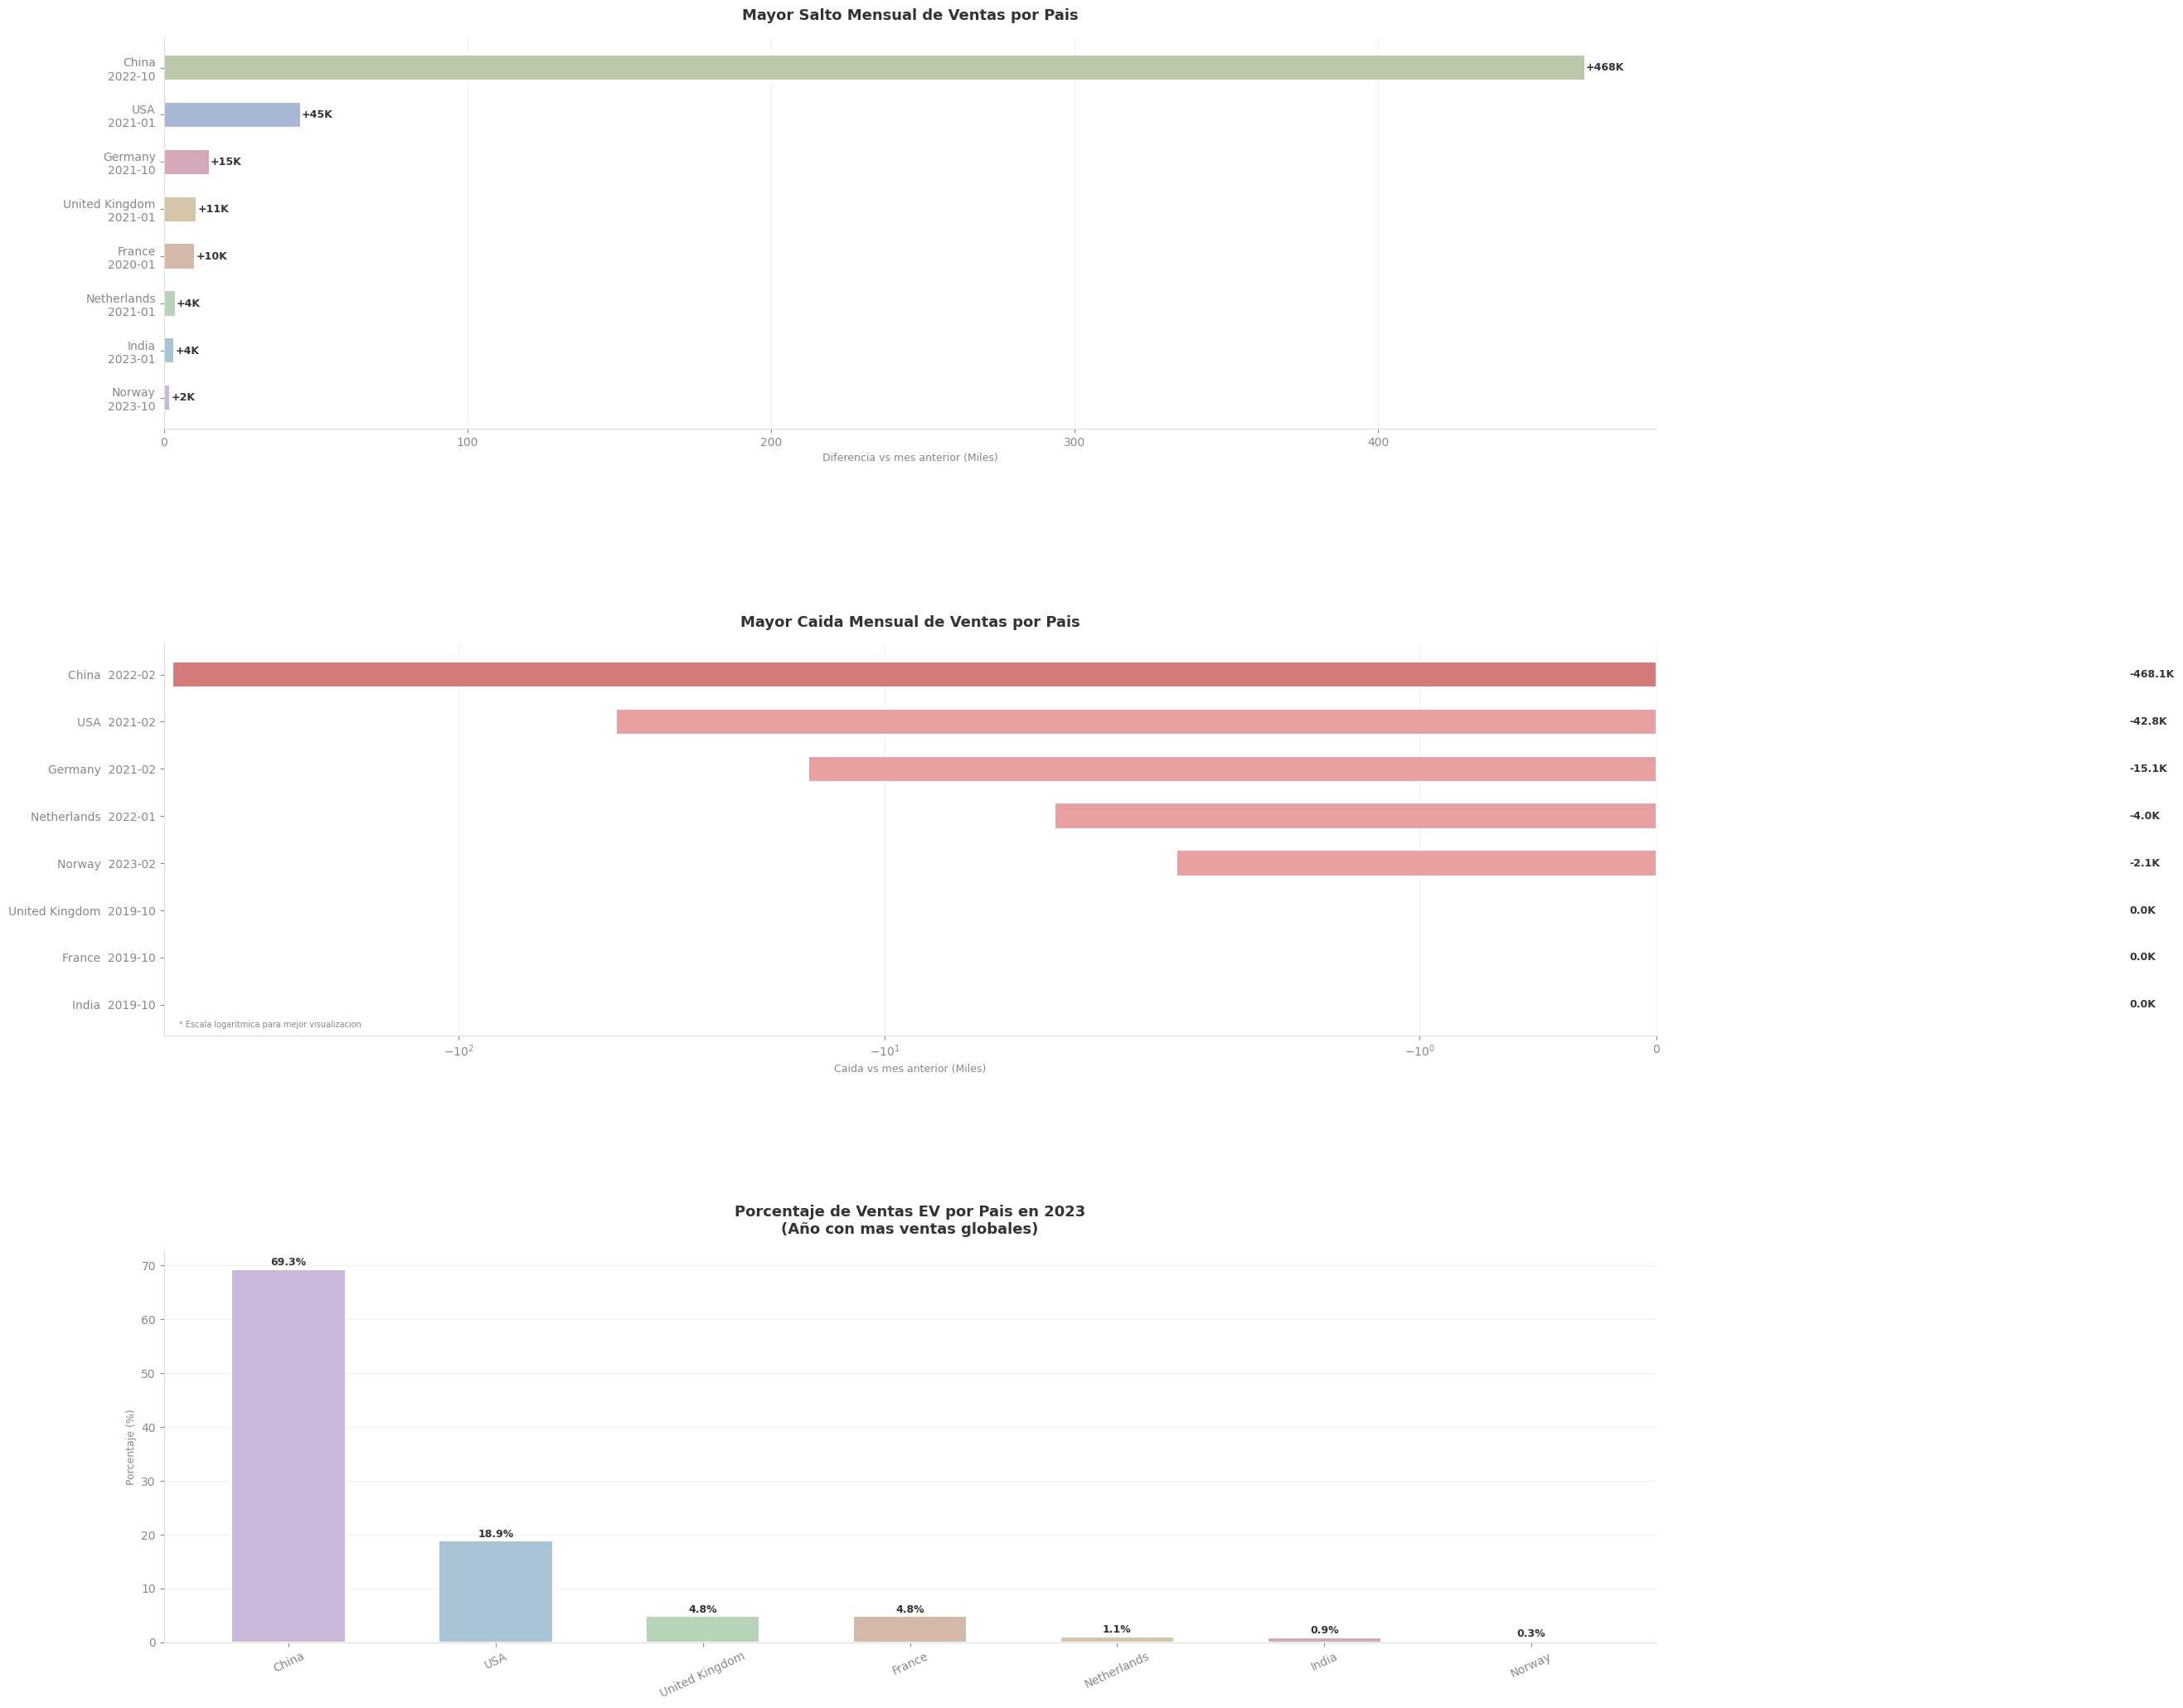

In [20]:
fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle('',
             fontsize=20, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(3, 1, figure=fig,
                       hspace=0.55,
                       left=0.07, right=0.97,
                       top=0.93, bottom=0.05)

# ── GRAFICO 10 — Horizontal bar chart Mayor salto de ventas por pais ───────────────
ax10 = fig.add_subplot(gs[0])
df10 = q10.sort_values('diferencia', ascending=True)
df10['label'] = df10['country_name'] + '\n' + \
                df10['year'].astype(str) + '-' + \
                df10['mes'].astype(str).str.zfill(2)

bars10 = ax10.barh(df10['label'],
                   df10['diferencia'] / 1000,
                   color=PASTEL[:len(df10)],
                   height=0.55,
                   edgecolor='white', linewidth=1.5)
ax10.set_title('Mayor Salto Mensual de Ventas por Pais',
               fontsize=13, fontweight='bold', color=TEXT, pad=15)
ax10.set_xlabel('Diferencia vs mes anterior (Miles)', 
                color=SUB, fontsize=9)
ax10.xaxis.grid(True, color=GRID)
ax10.set_axisbelow(True)
for bar, val in zip(bars10, df10['diferencia']):
    ax10.text(bar.get_width() + 0.3,
              bar.get_y() + bar.get_height()/2,
              f'+{val/1000:.0f}K',
              va='center', fontsize=9,
              fontweight='bold', color=TEXT)

#-------------- GRAFICO 11  Horizontal Bar Chart Mayor caida de ventas-------- 
ax11 = fig.add_subplot(gs[1])
df11 = q11.sort_values('diferencia', ascending=False)  # peor abajo
df11['label'] = (df11['country_name'] + '  ' +
                 df11['year'].astype(str) + '-' +
                 df11['mes'].astype(str).str.zfill(2))

cols11 = ['#D47A7A' if v == df11['diferencia'].min()
          else '#E8A0A0'
          for v in df11['diferencia']]

bars11 = ax11.barh(df11['label'],
                   df11['diferencia'] / 1000,
                   color=cols11,
                   height=0.55,
                   edgecolor='white', linewidth=1.5)

ax11.axvline(0, color='#CCCCCC', linewidth=1)
ax11.set_title('Mayor Caida Mensual de Ventas por Pais',
               fontsize=13, fontweight='bold', color=TEXT, pad=15)
ax11.set_xlabel('Caida vs mes anterior (Miles)',
                color=SUB, fontsize=9)
ax11.set_xscale('symlog')
ax11.xaxis.grid(True, color=GRID)
ax11.set_axisbelow(True)

for bar, val in zip(bars11, df11['diferencia']):
    ax11.text(2,                               
              bar.get_y() + bar.get_height()/2,
              f'{val/1000:.1f}K',
              va='center', ha='left',
              fontsize=9, fontweight='bold',
              color=TEXT)

ax11.text(0.01, 0.02,
          '* Escala logaritmica para mejor visualizacion',
          transform=ax11.transAxes,
          fontsize=7, color=SUB)

# ---------GRAFICO 12 Bar Chart Porcentaje ventas por pais en mejor año -------
ax12 = fig.add_subplot(gs[2])
df12 = q12.sort_values('porcentaje', ascending=False)
anio = df12['year'].iloc[0]

cols12 = [PASTEL[0] if v == df12['porcentaje'].max()
          else PASTEL[i % len(PASTEL)]
          for i, v in enumerate(df12['porcentaje'])]

bars12 = ax12.bar(df12['country_name'],
                  df12['porcentaje'],
                  color=cols12, width=0.55,
                  edgecolor='white', linewidth=1.5)
ax12.set_title(f'Porcentaje de Ventas EV por Pais en {anio}\n(Año con mas ventas globales)',
               fontsize=13, fontweight='bold', color=TEXT, pad=15)
ax12.set_ylabel('Porcentaje (%)', color=SUB, fontsize=9)
ax12.tick_params(axis='x', rotation=25)
ax12.yaxis.grid(True, color=GRID)
ax12.set_axisbelow(True)
for bar, val in zip(bars12, df12['porcentaje']):
    ax12.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.3,
              f'{val:.1f}%',
              ha='center', va='bottom',
              fontsize=9, fontweight='bold', color=TEXT)

plt.savefig('ev_dashboard_10_12.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()